<h3>Amogh Sahore<br>
2547108<br>
Machine Learning Lab 03</h3>

## Data-cleaning assumptions

- Values between 0 and 1 in percentage columns are treated as fractions and multiplied by 100.
- Nonnumeric placeholders (for example, `Option 1`, `na`, and `-`) become missing values.
- GPA is expected on a 4-point scale. Values above 4 through 10 are converted from a 10-point scale; values above 10 through 100 are converted from a percentage scale.
- CIA values below 40 after normalization are considered implausible survey-entry errors and are excluded from the CIA experiment.
- Exact duplicate rows are removed. If a registration number occurs more than once, the latest response is retained.
- Missing values are handled per experiment by dropping only rows missing that experiment's X or Y values.

In [1]:
#step 1: Import libraries and configure reproducibility
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [2]:
#step 2: Load the submitted CSV dataset, or create it from the Excel export if needed
CSV_FILE = Path('student_survey.csv')
EXCEL_FILE = Path('Department Awareness Survey (Responses).xlsx')

if CSV_FILE.exists():
    raw_df = pd.read_csv(CSV_FILE)
    print('Loaded:', CSV_FILE)
elif EXCEL_FILE.exists():
    raw_df = pd.read_excel(EXCEL_FILE)
    raw_df.to_csv(CSV_FILE, index=False)
    print('Loaded:', EXCEL_FILE)
    print('CSV created:', CSV_FILE)
else:
    raise FileNotFoundError('Place student_survey.csv or Department Awareness Survey (Responses).xlsx in the same folder as this notebook.')

Loaded: student_survey.csv


In [3]:
# Major step 3: Display the first five rows
raw_df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [4]:
#step 4: Check dataset dimensions and column names
print(f'Rows: {raw_df.shape[0]}, Columns: {raw_df.shape[1]}')
for index, column in enumerate(raw_df.columns, start=1):
    print(f'{index:02d}. {column!r}')

Rows: 54, Columns: 15
01. 'Timestamp'
02. 'Registration Number '
03. 'Email'
04. 'Job role that you are interested in\n'
05. 'What is the minimum salary of students placed through campus (In LPA..respond as a number)'
06. 'What is the maximum salary of students placed through campus (In LPA..respond as a number)'
07. 'What is the  median salary of students placed through campus (In LPA..respond as a number)'
08. 'Which is the highest paying company'
09. 'Rate your contribution towards extra curricular activities'
10. 'Rate your technical competencies'
11. 'What are your package expectations (LPA)'
12. 'your CIA % of last semester '
13. 'your GPA of last semester'
14. 'Your maximum attendance % till last semester'
15. 'Internships Interests'


In [5]:
#step 5: Identify missing values before cleaning
missing_before = raw_df.isna().sum().sort_values(ascending=False)
missing_before.to_frame('missing_count')

,missing_count
Timestamp,0
Registration Number,0
Email,0
Job role that you are interested in\n,0
What is the minimum salary of students placed through campus (In LPA..respond as a number),0
What is the maximum salary of students placed through campus (In LPA..respond as a number),0
What is the median salary of students placed through campus (In LPA..respond as a number),0
Which is the highest paying company,0
Rate your contribution towards extra curricular activities,0
Rate your technical competencies,0


In [6]:
#step 6: Select and rename the required survey columns
def find_column(columns, required_terms):
    matches = [c for c in columns if all(term.lower() in c.lower() for term in required_terms)]
    if len(matches) != 1:
        raise ValueError(f'Expected one column containing {required_terms}, found: {matches}')
    return matches[0]

registration_col = find_column(raw_df.columns, ['registration'])
cia_col = find_column(raw_df.columns, ['cia', '%'])
gpa_col = find_column(raw_df.columns, ['gpa'])
attendance_col = find_column(raw_df.columns, ['attendance', '%'])
timestamp_col = find_column(raw_df.columns, ['timestamp'])

df = raw_df.rename(columns={
    registration_col: 'Registration_Number',
    cia_col: 'CIA_Percentage',
    gpa_col: 'GPA',
    attendance_col: 'Attendance_Percentage',
    timestamp_col: 'Timestamp',
}).copy()

df[['Timestamp', 'Registration_Number', 'CIA_Percentage', 'GPA', 'Attendance_Percentage']].head()

,Timestamp,Registration_Number,CIA_Percentage,GPA,Attendance_Percentage
0,2026-06-22 08:49:31.362,2547123,78,3.24,Option 1
1,2026-06-22 08:49:50.520,2547122,64.78,3.2,Option 1
2,2026-06-22 08:50:44.521,2547101,80,3.6,Option 1
3,2026-06-22 08:51:00.666,2547156,70,3.2,92
4,2026-06-22 08:51:42.357,2547148,68,3.4,85


In [7]:
#step 7: Remove exact duplicates and repeated registrations
rows_initial = len(df)
exact_duplicates = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Registration_Number'] = df['Registration_Number'].astype('string').str.strip()
df = df.sort_values('Timestamp').drop_duplicates(subset='Registration_Number', keep='last').copy()

print('Initial rows:', rows_initial)
print('Exact duplicate rows removed:', exact_duplicates)
print('Repeated-registration rows removed:', rows_initial - exact_duplicates - len(df))
print('Rows remaining:', len(df))

Initial rows: 54
Exact duplicate rows removed: 0
Repeated-registration rows removed: 2
Rows remaining: 52


In [8]:
#step 8: Convert the regression columns to numeric and normalize scales
numeric_columns = ['CIA_Percentage', 'GPA', 'Attendance_Percentage']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

for column in ['CIA_Percentage', 'Attendance_Percentage']:
    fraction_mask = df[column].between(0, 1, inclusive='both')
    df.loc[fraction_mask, column] = df.loc[fraction_mask, column] * 100
    df.loc[~df[column].between(0, 100, inclusive='both'), column] = np.nan

gpa_from_10 = df['GPA'].gt(4) & df['GPA'].le(10)
gpa_from_100 = df['GPA'].gt(10) & df['GPA'].le(100)
df.loc[gpa_from_10, 'GPA'] = df.loc[gpa_from_10, 'GPA'] * (4 / 10)
df.loc[gpa_from_100, 'GPA'] = df.loc[gpa_from_100, 'GPA'] * (4 / 100)
df.loc[~df['GPA'].between(0, 4, inclusive='both'), 'GPA'] = np.nan

df[numeric_columns].dtypes

CIA_Percentage           float64
GPA                      float64
Attendance_Percentage    float64
dtype: object

In [9]:
#step 9: Review null values after numeric conversion
df[numeric_columns].isna().sum().to_frame('missing_after_cleaning')

,missing_after_cleaning
CIA_Percentage,1
GPA,1
Attendance_Percentage,4


In [10]:
#step 10: Generate the statistical summary
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CIA_Percentage,51.0,71.399608,15.228290,3.45,70.000,71.0,79.6650,89.0
GPA,51.0,3.492549,0.276383,2.90,3.385,3.5,3.6550,4.0
Attendance_Percentage,48.0,93.121458,4.807110,85.00,89.000,93.5,97.9925,100.0


In [11]:
#step 11: Select independent and dependent variables for both experiments
cia_data = df.loc[df['CIA_Percentage'].ge(40), ['CIA_Percentage', 'GPA']].dropna().copy()
attendance_data = df[['Attendance_Percentage', 'GPA']].dropna().copy()

print('Experiment 1 — X: CIA_Percentage, Y: GPA, usable rows:', len(cia_data))
print('Experiment 2 — X: Attendance_Percentage, Y: GPA, usable rows:', len(attendance_data))
display(cia_data.head())
display(attendance_data.head())

Experiment 1 — X: CIA_Percentage, Y: GPA, usable rows: 48
Experiment 2 — X: Attendance_Percentage, Y: GPA, usable rows: 47


,CIA_Percentage,GPA
2,80.0,3.6
3,70.0,3.2
4,68.0,3.4
5,70.0,3.5
6,88.0,3.7


,Attendance_Percentage,GPA
3,92.0,3.2
4,85.0,3.4
5,87.0,3.5
7,90.0,4.0
8,89.0,3.4


In [12]:
#step 12: Define the manual Ordinary Least Squares calculation
def manual_ols(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    x_mean, y_mean = x.mean(), y.mean()
    denominator = np.sum((x - x_mean) ** 2)
    if np.isclose(denominator, 0):
        raise ValueError('OLS slope is undefined because all X values are identical.')
    slope = np.sum((x - x_mean) * (y - y_mean)) / denominator
    intercept = y_mean - slope * x_mean
    return float(slope), float(intercept)

print('Slope formula: Σ((x - x̄)(y - ȳ)) / Σ((x - x̄)²)')
print('Intercept formula: ȳ - slope × x̄')

Slope formula: Σ((x - x̄)(y - ȳ)) / Σ((x - x̄)²)
Intercept formula: ȳ - slope × x̄


## Experiment 1: CIA Percentage predicts GPA

In [13]:
#step 13: Split CIA data into training and testing sets
X_cia = cia_data[['CIA_Percentage']]
y_cia = cia_data['GPA']
X_cia_train, X_cia_test, y_cia_train, y_cia_test = train_test_split(
    X_cia, y_cia, test_size=0.20, random_state=RANDOM_STATE
)
print('Training rows:', len(X_cia_train), '| Testing rows:', len(X_cia_test))

Training rows: 38 | Testing rows: 10


In [14]:
#step 14: Train Scikit-learn regression for CIA → GPA
cia_model = LinearRegression()
cia_model.fit(X_cia_train, y_cia_train)
cia_sklearn_slope = float(cia_model.coef_[0])
cia_sklearn_intercept = float(cia_model.intercept_)
cia_sklearn_predictions = cia_model.predict(X_cia_test)
print(f'Slope: {cia_sklearn_slope:.10f}')
print(f'Intercept: {cia_sklearn_intercept:.10f}')
print(f'Equation: GPA = {cia_sklearn_intercept:.6f} + ({cia_sklearn_slope:.6f} × CIA_Percentage)')

Slope: 0.0110265790
Intercept: 2.6338863024
Equation: GPA = 2.633886 + (0.011027 × CIA_Percentage)


In [15]:
#step 15: Compute the CIA regression equation manually using OLS
cia_ols_slope, cia_ols_intercept = manual_ols(X_cia_train.iloc[:, 0], y_cia_train)
cia_ols_predictions = cia_ols_intercept + cia_ols_slope * X_cia_test.iloc[:, 0].to_numpy()
print(f'Manual slope: {cia_ols_slope:.10f}')
print(f'Manual intercept: {cia_ols_intercept:.10f}')
print(f'Equation: GPA = {cia_ols_intercept:.6f} + ({cia_ols_slope:.6f} × CIA_Percentage)')

Manual slope: 0.0110265790
Manual intercept: 2.6338863024
Equation: GPA = 2.633886 + (0.011027 × CIA_Percentage)


In [16]:
#step 16: Compare Scikit-learn and manual OLS predictions for CIA
cia_comparison = pd.DataFrame({
    'CIA_Percentage': X_cia_test.iloc[:, 0].to_numpy(),
    'Actual_GPA': y_cia_test.to_numpy(),
    'Sklearn_Prediction': cia_sklearn_predictions,
    'Manual_OLS_Prediction': cia_ols_predictions,
})
cia_comparison['Absolute_Difference'] = (
    cia_comparison['Sklearn_Prediction'] - cia_comparison['Manual_OLS_Prediction']
).abs()
cia_comparison

,CIA_Percentage,Actual_GPA,Sklearn_Prediction,Manual_OLS_Prediction,Absolute_Difference
0,80.0,3.86,3.516013,3.516013,0.0
1,77.0,3.77,3.482933,3.482933,0.0
2,77.0,3.60,3.482933,3.482933,0.0
3,78.0,3.74,3.493959,3.493959,0.0
4,85.0,3.60,3.571146,3.571146,0.0
5,80.0,3.80,3.516013,3.516013,0.0
6,89.0,3.67,3.615252,3.615252,0.0
7,80.0,3.64,3.516013,3.516013,0.0
8,88.0,3.70,3.604225,3.604225,0.0
9,70.0,3.40,3.405747,3.405747,0.0


In [17]:
#step 17: Evaluate the CIA model on the fitted training data
cia_metric_predictions = cia_model.predict(X_cia_train)
cia_mse = mean_squared_error(y_cia_train, cia_metric_predictions)
cia_metrics = {
    'MAE': mean_absolute_error(y_cia_train, cia_metric_predictions),
    'MSE': cia_mse,
    'RMSE': cia_mse ** 0.5,
    'Training_R2': r2_score(y_cia_train, cia_metric_predictions),
    'Maximum_method_difference': cia_comparison['Absolute_Difference'].max(),
}
pd.Series(cia_metrics, name='CIA → GPA')

MAE                          0.180456
MSE                          0.057979
RMSE                         0.240788
Training_R2                  0.063332
Maximum_method_difference    0.000000
Name: CIA → GPA, dtype: float64

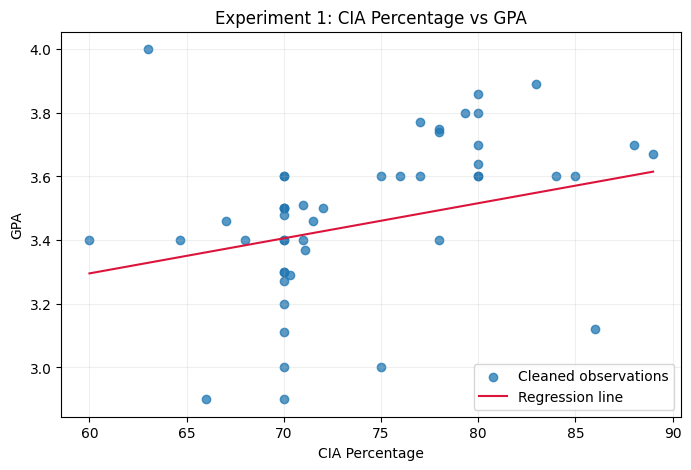

In [22]:
#step 18: Plot CIA percentage against GPA with the fitted line
x_line = np.linspace(cia_data['CIA_Percentage'].min(), cia_data['CIA_Percentage'].max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(cia_data['CIA_Percentage'], cia_data['GPA'], alpha=0.75, label='Cleaned observations')
plt.plot(x_line, cia_sklearn_intercept + cia_sklearn_slope * x_line, color='crimson', label='Regression line')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('Experiment 1: CIA Percentage vs GPA')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Experiment 2: Attendance Percentage predicts GPA

In [18]:
#step 19: Split attendance data into training and testing sets
X_att = attendance_data[['Attendance_Percentage']]
y_att = attendance_data['GPA']
X_att_train, X_att_test, y_att_train, y_att_test = train_test_split(
    X_att, y_att, test_size=0.20, random_state=RANDOM_STATE
)
print('Training rows:', len(X_att_train), '| Testing rows:', len(X_att_test))

Training rows: 37 | Testing rows: 10


In [19]:
#step 20: Train Scikit-learn regression for attendance → GPA
attendance_model = LinearRegression()
attendance_model.fit(X_att_train, y_att_train)
attendance_sklearn_slope = float(attendance_model.coef_[0])
attendance_sklearn_intercept = float(attendance_model.intercept_)
attendance_sklearn_predictions = attendance_model.predict(X_att_test)
print(f'Slope: {attendance_sklearn_slope:.10f}')
print(f'Intercept: {attendance_sklearn_intercept:.10f}')
print(f'Equation: GPA = {attendance_sklearn_intercept:.6f} + ({attendance_sklearn_slope:.6f} × Attendance_Percentage)')

Slope: 0.0255145234
Intercept: 1.1030658120
Equation: GPA = 1.103066 + (0.025515 × Attendance_Percentage)


In [20]:
#step 21: Compute the attendance regression equation manually using OLS
attendance_ols_slope, attendance_ols_intercept = manual_ols(X_att_train.iloc[:, 0], y_att_train)
attendance_ols_predictions = attendance_ols_intercept + attendance_ols_slope * X_att_test.iloc[:, 0].to_numpy()
print(f'Manual slope: {attendance_ols_slope:.10f}')
print(f'Manual intercept: {attendance_ols_intercept:.10f}')
print(f'Equation: GPA = {attendance_ols_intercept:.6f} + ({attendance_ols_slope:.6f} × Attendance_Percentage)')

Manual slope: 0.0255145234
Manual intercept: 1.1030658120
Equation: GPA = 1.103066 + (0.025515 × Attendance_Percentage)


In [21]:
#step 22: Compare Scikit-learn and manual OLS predictions for attendance
attendance_comparison = pd.DataFrame({
    'Attendance_Percentage': X_att_test.iloc[:, 0].to_numpy(),
    'Actual_GPA': y_att_test.to_numpy(),
    'Sklearn_Prediction': attendance_sklearn_predictions,
    'Manual_OLS_Prediction': attendance_ols_predictions,
})
attendance_comparison['Absolute_Difference'] = (
    attendance_comparison['Sklearn_Prediction'] - attendance_comparison['Manual_OLS_Prediction']
).abs()
attendance_comparison

,Attendance_Percentage,Actual_GPA,Sklearn_Prediction,Manual_OLS_Prediction,Absolute_Difference
0,94.00,3.60,3.501431,3.501431,0.0
1,88.00,3.50,3.348344,3.348344,0.0
2,96.00,3.86,3.552460,3.552460,0.0
3,98.71,3.60,3.621604,3.621604,0.0
4,85.00,3.40,3.271800,3.271800,0.0
5,89.00,3.30,3.373858,3.373858,0.0
6,94.25,3.37,3.507810,3.507810,0.0
7,85.00,3.60,3.271800,3.271800,0.0
8,89.00,3.40,3.373858,3.373858,0.0
9,97.00,3.60,3.577975,3.577975,0.0


In [22]:
#step 23: Evaluate the attendance model on the fitted training data
attendance_metric_predictions = attendance_model.predict(X_att_train)
attendance_mse = mean_squared_error(y_att_train, attendance_metric_predictions)
attendance_metrics = {
    'MAE': mean_absolute_error(y_att_train, attendance_metric_predictions),
    'MSE': attendance_mse,
    'RMSE': attendance_mse ** 0.5,
    'Training_R2': r2_score(y_att_train, attendance_metric_predictions),
    'Maximum_method_difference': attendance_comparison['Absolute_Difference'].max(),
}
pd.Series(attendance_metrics, name='Attendance → GPA')

MAE                          0.219767
MSE                          0.073766
RMSE                         0.271600
Training_R2                  0.152879
Maximum_method_difference    0.000000
Name: Attendance → GPA, dtype: float64

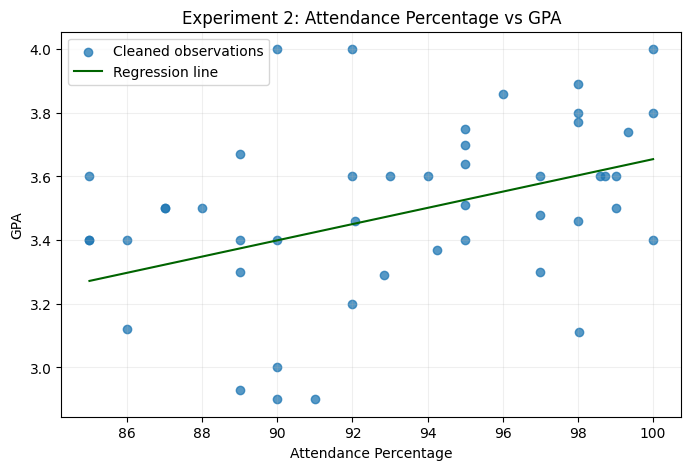

In [23]:
#step 24: Plot attendance percentage against GPA with the fitted line
x_line = np.linspace(attendance_data['Attendance_Percentage'].min(), attendance_data['Attendance_Percentage'].max(), 100)
plt.figure(figsize=(8, 5))
plt.scatter(attendance_data['Attendance_Percentage'], attendance_data['GPA'], alpha=0.75, label='Cleaned observations')
plt.plot(x_line, attendance_sklearn_intercept + attendance_sklearn_slope * x_line, color='darkgreen', label='Regression line')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Experiment 2: Attendance Percentage vs GPA')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Parameter saving and loading

In [24]:
#step 25: Save both models' learned slope and intercept using Pickle
learned_parameters = {
    'CIA_to_GPA': {'slope': cia_sklearn_slope, 'intercept': cia_sklearn_intercept},
    'Attendance_to_GPA': {
        'slope': attendance_sklearn_slope,
        'intercept': attendance_sklearn_intercept,
    },
}

PICKLE_FILE = Path('linear_regression_weights.pkl')
with PICKLE_FILE.open('wb') as file:
    pickle.dump(learned_parameters, file)
print('Saved:', PICKLE_FILE)
learned_parameters

Saved: linear_regression_weights.pkl


{'CIA_to_GPA': {'slope': 0.011026579043724906,
  'intercept': 2.6338863023760415},
 'Attendance_to_GPA': {'slope': 0.02551452344903064,
  'intercept': 1.1030658119827317}}

In [25]:
#step 26: Load the saved model parameters
with PICKLE_FILE.open('rb') as file:
    loaded_parameters = pickle.load(file)
loaded_parameters

{'CIA_to_GPA': {'slope': 0.011026579043724906,
  'intercept': 2.6338863023760415},
 'Attendance_to_GPA': {'slope': 0.02551452344903064,
  'intercept': 1.1030658119827317}}

In [26]:
#step 27: Use loaded parameters for new predictions
def predict_with_saved_parameters(experiment_name, x_value):
    parameters = loaded_parameters[experiment_name]
    return parameters['intercept'] + parameters['slope'] * x_value

sample_cia = 75.0
sample_attendance = 90.0
print(f'Predicted GPA for CIA {sample_cia:.1f}%: '
      f'{predict_with_saved_parameters("CIA_to_GPA", sample_cia):.4f}')
print(f'Predicted GPA for attendance {sample_attendance:.1f}%: '
      f'{predict_with_saved_parameters("Attendance_to_GPA", sample_attendance):.4f}')

Predicted GPA for CIA 75.0%: 3.4609
Predicted GPA for attendance 90.0%: 3.3994


In [27]:
#step 28: Produce final observations and inference
method_tolerance = 1e-10
results = pd.DataFrame([
    {
        'Experiment': 'CIA → GPA',
        'Slope': cia_sklearn_slope,
        'Intercept': cia_sklearn_intercept,
        **cia_metrics,
    },
    {
        'Experiment': 'Attendance → GPA',
        'Slope': attendance_sklearn_slope,
        'Intercept': attendance_sklearn_intercept,
        **attendance_metrics,
    },
])
display(results)

for _, row in results.iterrows():
    same = row['Maximum_method_difference'] < method_tolerance
    direction = 'positive' if row['Slope'] > 0 else 'negative' if row['Slope'] < 0 else 'no'
    print(f"{row['Experiment']}: Scikit-learn and manual OLS predictions "
          f"{'match to floating-point precision' if same else 'need investigation'}.")
    print(f"  The fitted line has a {direction} slope ({row['Slope']:.6f}) "
          f"and training R² = {row['Training_R2']:.4f}.")

best = results.loc[results['Training_R2'].idxmax()]
print(f"Among these two one-variable models, {best['Experiment']} has the higher training R². "
      'Interpret cautiously because the dataset is small and self-reported; association does not establish causation.')

,Experiment,Slope,Intercept,MAE,MSE,RMSE,Training_R2,Maximum_method_difference
0,CIA → GPA,0.011027,2.633886,0.180456,0.057979,0.240788,0.063332,0.0
1,Attendance → GPA,0.025515,1.103066,0.219767,0.073766,0.271600,0.152879,0.0


CIA → GPA: Scikit-learn and manual OLS predictions match to floating-point precision.
  The fitted line has a positive slope (0.011027) and training R² = 0.0633.
Attendance → GPA: Scikit-learn and manual OLS predictions match to floating-point precision.
  The fitted line has a positive slope (0.025515) and training R² = 0.1529.
Among these two one-variable models, Attendance → GPA has the higher training R². Interpret cautiously because the dataset is small and self-reported; association does not establish causation.
